# SVM + BỘ DỮ LIỆU KẾT HỢP

In [3]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Concatenate, Reshape, Embedding, GlobalAveragePooling1D, Lambda

# Nhập và tiền xử lý dữ liệu

In [6]:
data_amp = pd.read_csv(r'../CSV_20k/genBank_20k/AMP_GenBank_20k.csv')
data_amp = data_amp.sample(10000)

In [7]:
data_namp = pd.read_csv(r'../CSV_20k/genBank_20k/nAMP_GenBank_20k.csv')
data_namp = data_namp.sample(10000)

In [8]:
combinated_data = pd.concat([data_amp, data_namp], ignore_index=True)

In [9]:
data_amp1 = pd.read_csv(r'../CSV_20k/notGenBank_20k/AMP_notGenBank_20k.csv')
data_amp1 = data_amp1.sample(10000)

In [10]:
data_namp1 = pd.read_csv(r'../CSV_20k/notGenBank_20k/nAMP_notGenBank_20k.csv')
data_namp1 = data_namp1.sample(10000)

In [11]:
combinated_data1 = pd.concat([data_amp1, data_namp1], ignore_index=True)

In [12]:
combinated_data = pd.concat([combinated_data, combinated_data1], ignore_index=True)

In [13]:
data, data_test = train_test_split(combinated_data, test_size=0.3, stratify=combinated_data['Label'], random_state=42, shuffle=True)

### Cột "ID" có thể chỉ là một định danh duy nhất cho từng dòng, không mang ý nghĩa đặc biệt trong mô hình.

In [15]:
data = data.drop(columns=['ID'])
data_test = data_test.drop(columns=['ID'])

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28000 entries, 14136 to 32782
Columns: 128 entries, Label to solvent_accessibility_exposed_100%
dtypes: float64(126), object(2)
memory usage: 27.6+ MB


In [17]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 34342 to 19435
Columns: 128 entries, Label to solvent_accessibility_exposed_100%
dtypes: float64(126), object(2)
memory usage: 11.8+ MB


### Kiểm tra và xóa số lượng rows trùng lặp

In [19]:
data.duplicated().sum()

0

In [20]:
data_test.duplicated().sum()

0

In [21]:
data = data.drop_duplicates()
data_test = data_test.drop_duplicates()

In [23]:
data.duplicated().sum()

0

In [24]:
data_test.duplicated().sum()

0

### Kiểm tra xem có cột nào chứa giá trị NaN (khuyết thiếu) hay không.

In [26]:
null_columns_1 = data.columns[data.isnull().sum() > 0]
print(data[null_columns_1].isnull().sum())

null_columns_2 = data_test.columns[data_test.isnull().sum() > 0]
print(data[null_columns_2].isnull().sum())

Series([], dtype: float64)
Series([], dtype: float64)


### Phân loại các cột theo kiểu dữ liệu
#### - float_columns: Chứa các cột có kiểu dữ liệu float64 (biến số học).
#### - object_columns: Chứa các cột có kiểu dữ liệu object (biến dạng chuỗi).

In [28]:
float_columns = data.select_dtypes(include=['float64']).columns
object_columns = data.select_dtypes(include=['object']).columns

### Dữ liệu có 2 cột dạng chuỗi:
#### - Label: Có thể là nhãn phân loại (ví dụ: Antimicrobial vs Non-Antimicrobial hoặc 1 vs 0).
#### - Sequence: Chuỗi peptide cần dự đoán.

In [30]:
object_columns

Index(['Label', 'Sequence'], dtype='object')

### Chuyển đổi nhãn (Label) từ chuỗi sang số (0/1):
#### - Nếu Label == 'nAMP' → gán 0 (Không kháng khuẩn).
#### - Nếu không phải 'nAMP' → gán 1 (Kháng khuẩn).
### Chuyển đổi kiểu dữ liệu thành float để phù hợp với mô hình.

In [32]:
data.loc[:, 'Label'] = data['Label'].apply(lambda x: 0 if x == 'nAMP' else 1)
data['Label'] = data['Label'].astype(float)

data_test.loc[:, 'Label'] = data_test['Label'].apply(lambda x: 0 if x == 'nAMP' else 1)
data_test['Label'] = data_test['Label'].astype(float)

# data

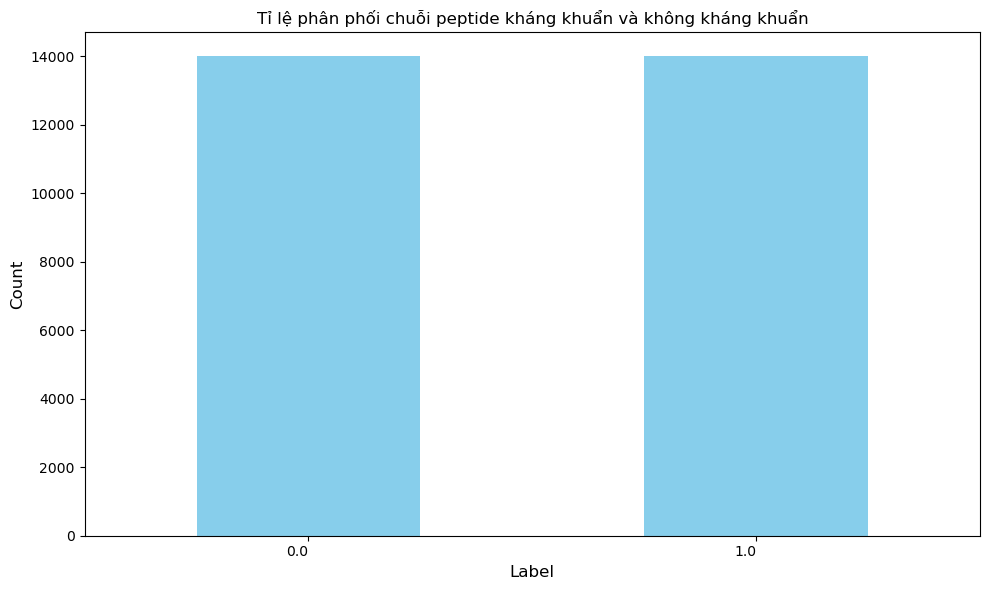

In [33]:
label_counts = data['Label'].value_counts()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color = 'skyblue')
plt.title('Tỉ lệ phân phối chuỗi peptide kháng khuẩn và không kháng khuẩn')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

In [36]:
x_test = data_test.drop(columns=['Label'])
y_test = data_test['Label']

X_train = data.drop(columns=['Label'])
y_train = data['Label']

### Kiểm tra (mẫu, đặc trưng)

In [38]:
print(x_test.shape)
print(y_test.shape)

print(X_train.shape)
print(y_train.shape)

(12000, 127)
(12000,)
(28000, 127)
(28000,)


In [39]:
X_val, X_test, Y_val, Y_test = train_test_split(x_test, y_test, test_size=0.5, stratify=y_test, random_state=42, shuffle=True)

### chuỗi sequence dạng chữ, chuyển về chuỗi số

In [41]:
# sequence_lengths = [len(seq) for seq in  data['Sequence']]  

# # Tính giá trị percentile 95%
# max_length = int(np.percentile(sequence_lengths, 95))  
# print(f"Max length hợp lý dựa trên 95% dữ liệu: {max_length}")

### Đệm hoặc cắt ở phía sau
###  Lý do chọn 'post':
#### - Giữ thông tin quan trọng ở đầu chuỗi, vì đầu peptide có thể chứa thông tin quan trọng về tính kháng khuẩn.

In [43]:
# pip install tensorflow

In [44]:
max_length = 50

padding_type = 'post' # Đệm thêm số 0
trunc_type = 'post'  # Cắt nếu chuỗi dài

In [45]:
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(data['Sequence'])
vocab_size = len(tokenizer.word_index) + 1
print("Vocab Size: ",vocab_size)

Vocab Size:  22


In [46]:
tokenizer.word_index

{'r': 1,
 'a': 2,
 'l': 3,
 'g': 4,
 'v': 5,
 'k': 6,
 's': 7,
 't': 8,
 'i': 9,
 'p': 10,
 'f': 11,
 'q': 12,
 'n': 13,
 'e': 14,
 'd': 15,
 'y': 16,
 'h': 17,
 'm': 18,
 'w': 19,
 'c': 20,
 'x': 21}

In [47]:
train_sequences  = tokenizer.texts_to_sequences(X_train['Sequence'])
train_sequence_array = pad_sequences(train_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

val_sequences = tokenizer.texts_to_sequences(X_val['Sequence'])
val_sequence_array = pad_sequences(val_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test['Sequence'])
test_sequence_array = pad_sequences(test_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

In [48]:
X_train= X_train.drop(columns=['Sequence'])
X_train['train_sequences'] = train_sequence_array.tolist()

X_val= X_val.drop(columns=['Sequence'])
X_val['val_sequences'] = val_sequence_array.tolist()

X_test= X_test.drop(columns=['Sequence'])
X_test['test_sequences'] = test_sequence_array.tolist()

In [49]:
X_train.describe()

,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,hydrophobicity_neutral_20%,hydrophobicity_neutral_40%,hydrophobicity_neutral_60%,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
count,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,...,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000
mean,0.213836,0.289218,0.503937,0.643801,0.855089,0.891613,0.211122,0.290487,0.460889,0.625741,...,0.435383,0.576210,0.693540,0.713669,0.213836,0.289218,0.503937,0.643801,0.855089,0.891613
std,0.177385,0.186141,0.202047,0.200710,0.170400,0.165943,0.173570,0.165528,0.176003,0.180295,...,0.237383,0.257529,0.282216,0.290085,0.177385,0.186141,0.202047,0.200710,0.170400,0.165943
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.100000,0.138587,0.357143,0.500000,0.800000,0.826087,0.100000,0.200000,0.333333,0.500000,...,0.289474,0.400000,0.600000,0.600000,0.100000,0.138587,0.357143,0.500000,0.800000,0.826087
50%,0.153846,0.250000,0.500000,0.700000,0.900000,1.000000,0.153846,0.266667,0.454545,0.631579,...,0.421053,0.600000,0.791667,0.800000,0.153846,0.250000,0.500000,0.700000,0.900000,1.000000
75%,0.300000,0.400000,0.649351,0.800000,1.000000,1.000000,0.300000,0.400000,0.600000,0.750000,...,0.600000,0.777778,0.900000,0.923077,0.300000,0.400000,0.649351,0.800000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [51]:
columns_with_max_equal_1 = X_train.columns[X_train.max() == 1]
columns_with_min_equal_0 = X_train.columns[X_train.min() == 0]

# In kết quả
print("Các cột có max == 1:", len(list(columns_with_max_equal_1)))
print("Các cột có min == 0:", len(list(columns_with_min_equal_0)))

Các cột có max == 1: 124
Các cột có min == 0: 123


## Kiểm tra X_train
#### Tổng có 127 cột. Tách thành 126 + 1 cột mảng

In [53]:
print(X_train.dtypes.value_counts())

float64    126
object       1
Name: count, dtype: int64


In [54]:
X_train_num = X_train.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_train_text = X_train.iloc[:, -1]   # Chọn cột cuối cùng

In [55]:
object_cols = X_train.select_dtypes(include=['object']).columns
print("Cột object:", object_cols)

Cột object: Index(['train_sequences'], dtype='object')


In [56]:
print(X_train_text.head(10))  # Xem 10 dòng đầu

14136    [13, 12, 17, 5, 10, 1, 12, 9, 7, 8, 0, 0, 0, 0...
30437    [5, 7, 13, 2, 7, 10, 8, 7, 7, 7, 0, 0, 0, 0, 0...
810      [5, 5, 2, 10, 5, 2, 2, 5, 3, 8, 1, 1, 2, 10, 1...
21267    [9, 1, 9, 2, 11, 4, 7, 9, 1, 8, 12, 3, 3, 1, 8...
18040    [1, 17, 13, 17, 1, 5, 2, 3, 8, 17, 0, 0, 0, 0,...
24981    [3, 1, 11, 9, 7, 2, 5, 5, 1, 1, 0, 0, 0, 0, 0,...
30008    [13, 6, 1, 12, 3, 10, 6, 10, 15, 12, 0, 0, 0, ...
21860    [1, 6, 9, 4, 17, 11, 5, 8, 17, 6, 10, 19, 5, 5...
12046    [8, 16, 2, 6, 1, 2, 12, 5, 7, 7, 0, 0, 0, 0, 0...
24035    [6, 3, 3, 10, 3, 2, 11, 5, 3, 16, 3, 9, 10, 5,...
Name: train_sequences, dtype: object


## Kiểm tra X_val
#### Tổng có 127 cột. Tách thành 126 + 1 cột mảng

In [59]:
print(X_val.dtypes.value_counts())

float64    126
object       1
Name: count, dtype: int64


In [60]:
X_val_num = X_val.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_val_text = X_val.iloc[:, -1]   # Chọn cột cuối cùng

In [63]:
print(X_val_text.head(10))  # Xem 10 dòng đầu

18096    [17, 5, 8, 4, 6, 7, 1, 8, 16, 3, 0, 0, 0, 0, 0...
38495    [14, 1, 11, 7, 16, 16, 2, 18, 1, 7, 0, 0, 0, 0...
31614    [16, 19, 15, 1, 15, 6, 5, 1, 3, 6, 0, 0, 0, 0,...
36960    [13, 3, 15, 6, 3, 12, 7, 1, 6, 5, 0, 0, 0, 0, ...
25563    [11, 2, 10, 18, 3, 4, 8, 3, 9, 4, 3, 4, 5, 4, ...
4958     [1, 1, 5, 3, 5, 8, 4, 2, 4, 5, 2, 4, 1, 0, 0, ...
33284    [2, 12, 12, 12, 2, 2, 14, 7, 7, 1, 0, 0, 0, 0,...
5432     [3, 1, 8, 4, 4, 1, 1, 3, 2, 4, 0, 0, 0, 0, 0, ...
29927    [2, 2, 6, 4, 4, 1, 1, 8, 3, 2, 4, 4, 0, 0, 0, ...
22615    [10, 1, 4, 10, 1, 7, 3, 19, 7, 12, 5, 13, 1, 1...
Name: val_sequences, dtype: object


## Kiểm tra dữ liệu huấn luyện
In thử một vài giá trị trong X_train và X_val để kiểm tra xem có giá trị âm hoặc không hợp lệ không

In [65]:
print(f"X_train_text - NaN: {pd.isna(X_train_text).sum()} / Total: {X_train_text.size}")
print(f"X_val_text - NaN: {pd.isna(X_val_text).sum()} / Total: {X_val_text.size}")

X_train_text - NaN: 0 / Total: 28000
X_val_text - NaN: 0 / Total: 6000


In [66]:
# X_train_num = np.array(X_train_num, dtype=np.float32)
# X_val_num = np.array(X_val_num, dtype=np.float32)
X_train_num = X_train_num.to_numpy(dtype=np.float32)
X_val_num = X_val_num.to_numpy(dtype=np.float32)

In [68]:
# Định nghĩa độ dài cố định cho X_train_text và X_val_text
max_len = max_length  

# Chuyển đổi tất cả thành danh sách cùng kích thước
X_train_text = np.array([seq[:max_len] + [0] * (max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in X_train_text], dtype=np.int32)

X_val_text = np.array([seq[:max_len] + [0] * (max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in X_val_text], dtype=np.int32)

print("X_train_text shape:", X_train_text.shape)
print("X_val_text shape:", X_val_text.shape)

X_train_text shape: (28000, 50)
X_val_text shape: (6000, 50)


# MODEL SVM

In [70]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Giả sử bạn đã có các biến sau:
# X_train_seq: Đặc trưng sequence (shape: [n_samples, maxlen=50])
# X_train_num: Đặc trưng số học (shape: [n_samples, 126])
# y_train: Nhãn (0: không kháng khuẩn, 1: kháng khuẩn)

# Bước 1: Kết hợp đặc trưng
def combine_features(sequence_features, numeric_features):
    """
    Kết hợp đặc trưng sequence và numeric
    
    Args:
        sequence_features: array shape [n_samples, maxlen]
        numeric_features: array shape [n_samples, 126]
    
    Returns:
        combined_features: array shape [n_samples, maxlen + 126]
    """
    return np.concatenate([sequence_features, numeric_features], axis=1)

# Kết hợp đặc trưng cho tập train, validation và test
X_train_combined = combine_features(X_train_text, X_train_num)
X_val_combined = combine_features(X_val_text, X_val_num)

In [71]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
)

In [75]:
# Bước 3: Huấn luyện mô hình
svm_model.fit(X_train_combined, y_train)

SVC(probability=True)


Validation Set Evaluation:
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      3000
         1.0       0.98      0.96      0.97      3000

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000

AUC Score: 0.9962


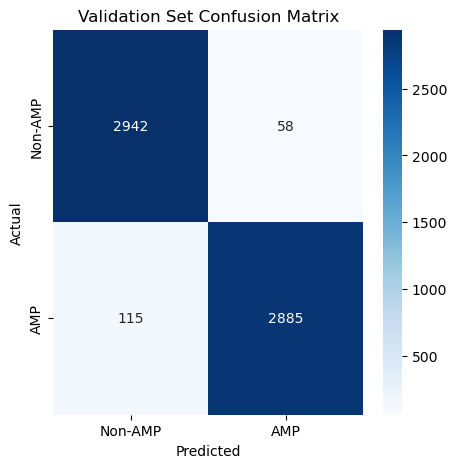

In [76]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X, y, set_name="Validation"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]  # Xác suất lớp dương
    
    print(f"\n{set_name} Set Evaluation:")
    print(classification_report(y, y_pred))
    print(f"AUC Score: {roc_auc_score(y, y_prob):.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-AMP', 'AMP'],
                yticklabels=['Non-AMP', 'AMP'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{set_name} Set Confusion Matrix')
    plt.show()

# Đánh giá trên tập validation và test
evaluate_model(svm_model, X_val_combined, Y_val, "Validation") 

In [77]:
import pickle

# Lưu mô hình
with open("svm_combination.pkl", "wb") as f:
    pickle.dump(svm_model, f)

# EXPLAINABLE AI

In [79]:
import pickle

# Tải lại mô hình
with open("svm_combination.pkl", "rb") as f:
    svm_model = pickle.load(f)

  0%|          | 0/1 [00:00<?, ?it/s]

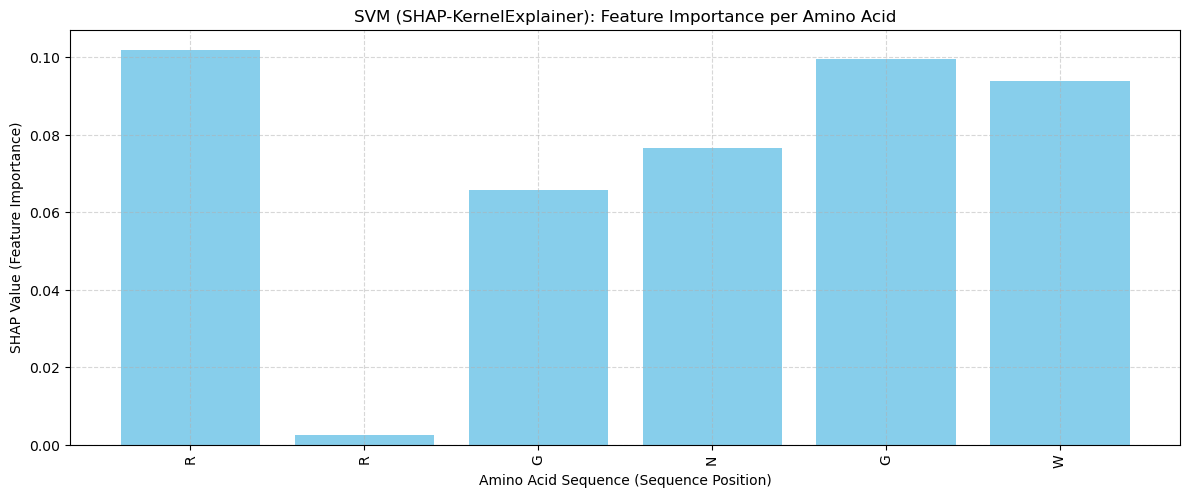

In [81]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy sample cần giải thích và dữ liệu nền
x_input_flat = X_val_combined[150:151]
x_seq = x_input_flat[:, :50]
background = X_val_combined[:100]

# 2. Tạo SHAP explainer
explainer = shap.KernelExplainer(svm_model.predict_proba, background)

# 3. Tính SHAP values cho class 1 (index 1 nếu là binary)
shap_values = explainer.shap_values(x_input_flat, nsamples=100)

# 4. Trích SHAP values phần sequence (0-49)
aa_shap_values = shap_values[0][:50, 1]

# 5. Mapping index → ký tự
token_indices = x_seq[0].flatten().astype(int)
index_to_char = {v: k.upper() for k, v in tokenizer.word_index.items()}
index_to_char[0] = 'PAD'
feature_names = [index_to_char.get(idx, '?') for idx in token_indices]

# 6. Bỏ PAD và các SHAP = 0
filtered_feature_names = []
filtered_saliency = []

for name, score in zip(feature_names, aa_shap_values):
    if name != 'PAD' and score != 0:
        filtered_feature_names.append(name)
        filtered_saliency.append(score)

# 7. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.bar(range(len(filtered_saliency)), filtered_saliency, color='skyblue')
plt.xticks(range(len(filtered_feature_names)), filtered_feature_names, rotation=90)
plt.xlabel("Amino Acid Sequence (Sequence Position)")
plt.ylabel("SHAP Value (Feature Importance)")
plt.title("SVM (SHAP-KernelExplainer): Feature Importance per Amino Acid")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()
